# Customer Cohort Retention Analysis

Customer retention is a key health metric for subscription SaaS businesses. Cohort retention analysis groups customers by their signup month and tracks the percentage of active customers over subsequent periods. This notebook simulates user activity records, groups them into monthly cohorts, and visualizes retention decay using a Seaborn heatmap.



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate simulated user signups and activity records over 12 months (2025-01 to 2025-12)
np.random.seed(42)
n_users = 4500

# Assign signup months
signup_months = np.random.choice(range(1, 13), size=n_users, p=[0.12, 0.10, 0.09, 0.08, 0.08, 0.07, 0.07, 0.07, 0.07, 0.08, 0.09, 0.08])
user_ids = [f"U_{i+1:04d}" for i in range(n_users)]

df_users = pd.DataFrame({
    'User_ID': user_ids,
    'Signup_Month': signup_months
})

# Generate monthly activity logs (retention drops over time)
activity_records = []
for index, row in df_users.iterrows():
    uid = row['User_ID']
    start_m = row['Signup_Month']
    
    # Retention decay parameters (older cohorts decay slightly more)
    decay_rate = np.random.uniform(0.12, 0.22)
    
    # Month 0 (signup month) is always active
    activity_records.append({'User_ID': uid, 'Cohort_Month': start_m, 'Month_Offset': 0})
    
    # Active state for subsequent months (up to Month 12)
    for offset in range(1, 13 - start_m + 1):
        # Probability of being active drops exponentially over time
        p_active = np.exp(-decay_rate * offset)
        if np.random.rand() < p_active:
            activity_records.append({
                'User_ID': uid,
                'Cohort_Month': start_m,
                'Month_Offset': offset
            })

df_activity = pd.DataFrame(activity_records)
df_activity.head(10)



,User_ID,Cohort_Month,Month_Offset
0,U_0001,4,0
1,U_0001,4,1
2,U_0001,4,2
3,U_0001,4,3
4,U_0001,4,5
5,U_0001,4,7
6,U_0002,12,0
7,U_0002,12,1
8,U_0003,9,0
9,U_0003,9,1


## Cohort Retention Matrix Computation

We calculate the absolute user counts for each cohort-offset pair, pivot the table, and divide each column by the starting cohort size (Month Offset 0) to obtain percentage retention matrices.



In [2]:
# Group by cohort and month offset to get active counts
cohort_group = df_activity.groupby(['Cohort_Month', 'Month_Offset'])['User_ID'].nunique()
df_cohort_counts = cohort_group.unstack(fill_value=0)

# Extract cohort sizes (active users at Offset 0)
cohort_sizes = df_cohort_counts.iloc[:, 0]

# Compute percentage retention matrix
df_retention = df_cohort_counts.divide(cohort_sizes, axis=0)

# Map numeric months to descriptive names
month_names = {
    1: 'Jan 2025', 2: 'Feb 2025', 3: 'Mar 2025', 4: 'Apr 2025', 
    5: 'May 2025', 6: 'Jun 2025', 7: 'Jul 2025', 8: 'Aug 2025', 
    9: 'Sep 2025', 10: 'Oct 2025', 11: 'Nov 2025', 12: 'Dec 2025'
}
df_retention.index = df_retention.index.map(month_names)

print("Cohort Size (Absolute Signups):")
print(cohort_sizes)
print("\nRetention Matrix (%):")
df_retention.iloc[:5, :5]



Cohort Size (Absolute Signups):
Cohort_Month
1     575
2     436
3     407
4     347
5     359
6     291
7     332
8     351
9     296
10    374
11    378
12    354
Name: 0, dtype: int64

Retention Matrix (%):


Month_Offset,0,1,2,3,4
Cohort_Month,,,,,
Jan 2025,1.0,0.841739,0.693913,0.579130,0.518261
Feb 2025,1.0,0.860092,0.697248,0.612385,0.497706
Mar 2025,1.0,0.882064,0.717445,0.611794,0.545455
Apr 2025,1.0,0.824207,0.737752,0.662824,0.504323
May 2025,1.0,0.827298,0.727019,0.593315,0.523677


## Cohort Decay Visualization Heatmap

Using Seaborn, we visualize the cohort retention decay matrix as an annotated heatmap, showing how different cohorts retain active users over time.



<cell>:17: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



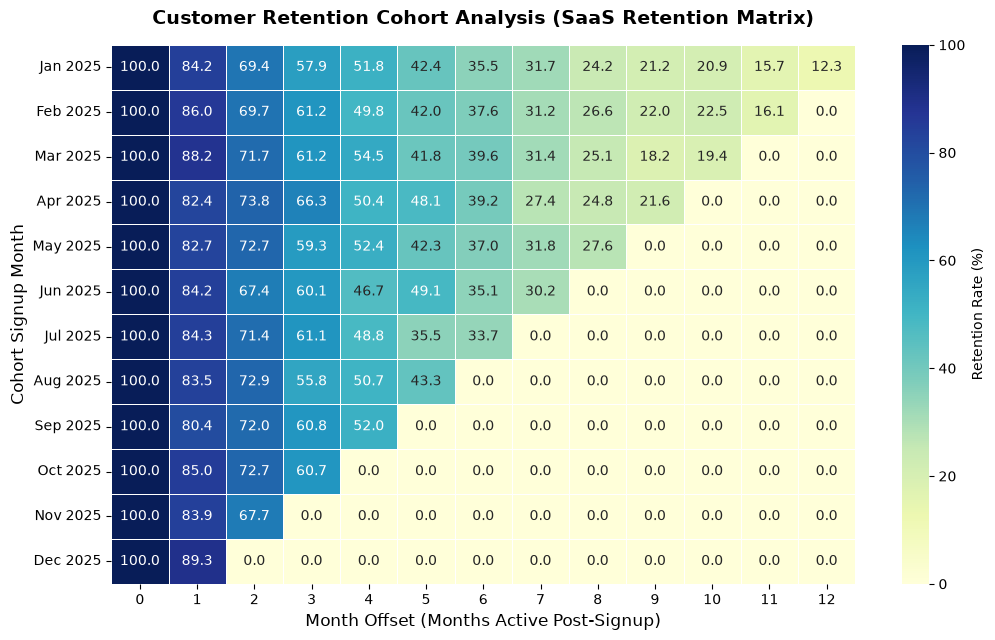

In [3]:
plt.figure(figsize=(12, 7))

# Plot heatmap
sns.heatmap(
    df_retention * 100, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)

plt.title('Customer Retention Cohort Analysis (SaaS Retention Matrix)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month Offset (Months Active Post-Signup)', fontsize=12)
plt.ylabel('Cohort Signup Month', fontsize=12)
plt.grid(False)
plt.show()
